# 生成质量监测

| 指标名                           | 含义          |
| :---------------------------- | :---------- |
| `response_length/mean`        | 生成序列平均长度    |
| `response_length/max`         | 生成序列最大长度    |
| `response_length/min`         | 生成序列最小长度    |
| `prompt_length/mean`          | Prompt 平均长度 |
| `completion/unique_sequences` | 批次内唯一序列比例   |

## 诊断价值：
- response_length <font color='red'>突然增长 → 奖励黑客（如通过重复无意义内容刷分）</font>
- unique_sequences <font color='red'>下降 → 模式崩溃，模型开始重复固定模板</font>

# 五大核心指标详解

## response_length/mean —— 生成序列平均长度



In [1]:
from IPython.display import Image

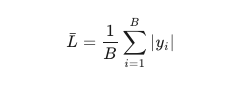

In [2]:
Image(filename='./Image/response_length.png')

### 诊断价值：
- 持续上升：模型可能在"凑字数"刷奖励（如某些任务奖励与长度正相关）
- 持续下降：模型可能学会了"偷懒"，用最短序列敷衍
- 剧烈波动：训练不稳定，策略在探索不同长度策略

## response_length/max —— 最大长度
用于检测极端异常生成：
- 突然接近 max_position_embeddings → 模型陷入无限循环（如重复 <|endoftext|> 前的内容）
- 频繁触发长度上限 → 思考预算（thinking budget）不足，或模型尚未学会终止

## response_length/min —— 最小长度
检测极简回答：
- 接近 1~2 个 token → 模型可能输出空内容或单个标点，完全放弃推理
- 在数学任务中，min 长度骤降可能意味着模型直接猜答案
##  prompt_length/mean —— Prompt 平均长度
主要用于数据分布监控：
- 训练过程中 prompt 长度不应变化（除非使用动态课程）
- 如果变化，说明数据加载器或预处理有 bug

## completion/unique_sequences —— 唯一序列比例

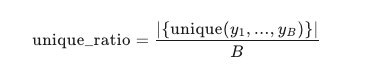

In [3]:
Image(filename='./Image/unique_sequences.png')

最重要的多样性指标：
- = 1.0：所有生成完全不同，探索充分
- < 0.5：超过一半样本重复，模式崩溃警告
- = 1/B：所有样本完全相同，完全崩溃

## 补充指标（工程实践中关键）


| 指标                    | 含义                     | 诊断       |
| :-------------------- | :--------------------- | :------- |
| `distinct_1`          | 生成中唯一 unigram 比例       | 词汇丰富度    |
| `distinct_2`          | 生成中唯一 bigram 比例        | 短语多样性    |
| `repetition_ratio`    | 连续重复 n-gram 比例         | 是否陷入循环生成 |
| `eos_usage_rate`      | 正确使用结束符比例              | 是否学会终止   |
| `special_token_ratio` | 特殊标记（如 `<think/>`）使用频率 | 格式遵循度    |


## 完整生成质量监控类

In [ ]:
import torch
import numpy as np
from collections import defaultdict, Counter
import math

class GenerationQualityMonitor:
    """
    verl 风格的生成质量监测器
    覆盖：长度统计、多样性、重复检测、模式崩溃识别
    """
    def __init__(self, eos_token_id=None, pad_token_id=None, 
                 max_length_limit=4096, repetition_window=3):
        self.eos_token_id = eos_token_id
        self.pad_token_id = pad_token_id
        self.max_length_limit = max_length_limit
        self.repetition_window = repetition_window
        self.history = defaultdict(list)
    
    def compute_length_stats(self, generated_ids, attention_mask=None):
        """
        计算生成序列长度统计
        
        Args:
            generated_ids: [B, T] 生成的 token IDs
            attention_mask: [B, T] 可选，用于处理 padding
        """
        if attention_mask is not None:
            # 按 attention_mask 计算实际长度
            lengths = attention_mask.sum(dim=1).cpu().numpy()
        else:
            # 假设无 padding，找 eos 位置
            B, T = generated_ids.shape
            lengths = []
            for i in range(B):
                seq = generated_ids[i].cpu().tolist()
                # 找第一个 eos 或 pad
                end = T
                for j, tid in enumerate(seq):
                    if tid == self.eos_token_id or tid == self.pad_token_id:
                        end = j
                        break
                lengths.append(end)
            lengths = np.array(lengths)
        
        stats = {
            'mean': float(np.mean(lengths)),
            'std': float(np.std(lengths)),
            'max': int(np.max(lengths)),
            'min': int(np.min(lengths)),
            'median': float(np.median(lengths)),
            'p95': float(np.percentile(lengths, 95)),
            'hit_max_limit': float(np.mean(lengths >= self.max_length_limit * 0.95)),
        }
        
        for k, v in stats.items():
            self.history[f'length_{k}'].append(v)
        
        return stats
    
    def compute_diversity(self, generated_ids):
        """
        计算文本多样性指标
        """
        B, T = generated_ids.shape
        sequences = [tuple(generated_ids[i].cpu().tolist()) for i in range(B)]
        
        # 1. 唯一序列比例
        unique_seqs = len(set(sequences))
        unique_ratio = unique_seqs / B
        
        # 2. Distinct-1 / Distinct-2
        def distinct_ngrams(token_lists, n):
            ngrams = set()
            total = 0
            for tokens in token_lists:
                # 过滤 pad
                valid = [t for t in tokens if t != self.pad_token_id]
                for i in range(len(valid) - n + 1):
                    ngrams.add(tuple(valid[i:i+n]))
                    total += 1
            return len(ngrams) / max(total, 1)
        
        token_lists = [generated_ids[i].cpu().tolist() for i in range(B)]
        d1 = distinct_ngrams(token_lists, 1)
        d2 = distinct_ngrams(token_lists, 2)
        
        # 3. 重复检测（连续 n-gram 重复）
        repetition_scores = []
        for tokens in token_lists:
            valid = [t for t in tokens if t != self.pad_token_id]
            if len(valid) < self.repetition_window * 2:
                repetition_scores.append(0.0)
                continue
            
            repeats = 0
            seen = set()
            for i in range(len(valid) - self.repetition_window + 1):
                ngram = tuple(valid[i:i+self.repetition_window])
                if ngram in seen:
                    repeats += 1
                seen.add(ngram)
            
            repetition_scores.append(repeats / max(len(valid) - self.repetition_window + 1, 1))
        
        avg_repetition = np.mean(repetition_scores)
        
        # 4. 熵（基于 token 频率）
        all_tokens = [t for seq in token_lists for t in seq if t != self.pad_token_id]
        if len(all_tokens) > 0:
            counts = Counter(all_tokens)
            probs = np.array(list(counts.values())) / len(all_tokens)
            entropy = -np.sum(probs * np.log(probs + 1e-10))
        else:
            entropy = 0.0
        
        metrics = {
            'unique_sequences': unique_ratio,
            'distinct_1': d1,
            'distinct_2': d2,
            'repetition_ratio': avg_repetition,
            'token_entropy': entropy,
        }
        
        for k, v in metrics.items():
            self.history[k].append(v)
        
        return metrics
    
    def detect_reward_hacking(self, length_stats, reward_stats=None):
        """
        检测奖励黑客行为
        """
        alerts = []
        
        # 信号 1：长度突然增长
        if len(self.history['length_mean']) >= 3:
            recent = self.history['length_mean'][-3:]
            if recent[-1] > recent[0] * 1.5 and recent[-1] > 100:
                alerts.append(
                    f"🚨 奖励黑客嫌疑：平均长度从 {recent[0]:.0f} 暴涨到 {recent[-1]:.0f}，"
                    f"可能通过重复无意义内容刷分"
                )
        
        # 信号 2：大量样本触达长度上限
        if length_stats.get('hit_max_limit', 0) > 0.3:
            alerts.append(
                f"🚨 长度上限频繁触发：{length_stats['hit_max_limit']*100:.1f}% 的样本达到 max_length，"
                f"模型可能陷入无限循环"
            )
        
        # 信号 3：长度与奖励高度正相关（需外部传入 reward_stats）
        if reward_stats and len(self.history['length_mean']) > 10:
            # 简化检测：如果长度持续增加且奖励也持续增加
            length_trend = np.polyfit(range(10), self.history['length_mean'][-10:], 1)[0]
            if length_trend > 5:  # 长度每步增加超过 5 个 token
                alerts.append(
                    f"⚠️ 长度-奖励正相关嫌疑：长度趋势斜率 {length_trend:.2f}，"
                    f"建议检查奖励函数是否与长度正相关"
                )
        
        return alerts
    
    def detect_mode_collapse(self, diversity_metrics):
        """
        检测模式崩溃
        """
        alerts = []
        
        unique_ratio = diversity_metrics['unique_sequences']
        distinct_2 = diversity_metrics['distinct_2']
        repetition = diversity_metrics['repetition_ratio']
        
        # 信号 1：唯一序列比例骤降
        if unique_ratio < 0.3:
            alerts.append(
                f"🚨 严重模式崩溃：唯一序列比例仅 {unique_ratio*100:.1f}%，"
                f"超过 70% 的样本在重复相同内容！"
            )
        elif unique_ratio < 0.6:
            alerts.append(
                f"⚠️ 模式崩溃警告：唯一序列比例 {unique_ratio*100:.1f}%，多样性不足"
            )
        
        # 信号 2：Distinct-2 极低
        if distinct_2 < 0.05:
            alerts.append(
                f"🚨 Bigram 多样性崩溃：Distinct-2 = {distinct_2:.4f}，"
                f"模型几乎只使用固定短语组合"
            )
        
        # 信号 3：高重复率
        if repetition > 0.3:
            alerts.append(
                f"🚨 循环生成检测：连续 {self.repetition_window}-gram 重复率 {repetition*100:.1f}%，"
                f"模型陷入重复输出"
            )
        
        return alerts
    
    def diagnose(self, step, generated_ids, attention_mask=None, reward_stats=None):
        """
        综合诊断入口
        """
        print(f"\n{'='*70}")
        print(f"Step {step} 生成质量诊断")
        print(f"{'='*70}")
        
        # 1. 长度统计
        length_stats = self.compute_length_stats(generated_ids, attention_mask)
        print(f"【长度统计】mean={length_stats['mean']:.1f}, "
              f"std={length_stats['std']:.1f}, "
              f"max={length_stats['max']}, min={length_stats['min']}, "
              f"median={length_stats['median']:.1f}")
        
        # 2. 多样性
        diversity = self.compute_diversity(generated_ids)
        print(f"【多样性】unique={diversity['unique_sequences']*100:.1f}%, "
              f"D1={diversity['distinct_1']:.3f}, "
              f"D2={diversity['distinct_2']:.3f}, "
              f"repetition={diversity['repetition_ratio']*100:.1f}%")
        
        # 3. 奖励黑客检测
        hack_alerts = self.detect_reward_hacking(length_stats, reward_stats)
        if hack_alerts:
            print(f"\n【奖励黑客检测】")
            for alert in hack_alerts:
                print(f"  {alert}")
        
        # 4. 模式崩溃检测
        collapse_alerts = self.detect_mode_collapse(diversity)
        if collapse_alerts:
            print(f"\n【模式崩溃检测】")
            for alert in collapse_alerts:
                print(f"  {alert}")
        
        # 5. 综合健康评分
        health = self._health_score(length_stats, diversity)
        print(f"\n【健康评分】{health:.1f}/100")
        if health < 50:
            print(f"   🚨 生成质量严重恶化，建议立即检查训练配置！")
        elif health < 70:
            print(f"   ⚠️ 生成质量下降，建议关注并准备干预")
        else:
            print(f"   ✅ 生成质量健康")
        
        print(f"{'='*70}")
        
        return {
            'length': length_stats,
            'diversity': diversity,
            'health': health,
        }
    
    def _health_score(self, length_stats, diversity):
        """
        综合健康评分（0-100）
        """
        score = 100.0
        
        # 多样性扣分
        score -= max(0, (1 - diversity['unique_sequences']) * 50)
        score -= max(0, (0.3 - diversity['distinct_2']) * 100)
        score -= min(50, diversity['repetition_ratio'] * 100)
        
        # 长度异常扣分
        if length_stats['hit_max_limit'] > 0.3:
            score -= 20
        if length_stats['min'] <= 1:
            score -= 15
        
        return max(0, score)


# ==================== 使用示例 ====================

print("=" * 70)
print("场景 1：正常训练（健康生成）")
print("=" * 70)

monitor = GenerationQualityMonitor(eos_token_id=2, pad_token_id=0)

# 模拟 20 个 batch
vocab_size = 1000
for step in range(20):
    B, T = 8, 50
    
    # 正常生成：有一定随机性
    generated = torch.randint(3, vocab_size, (B, T))
    # 随机插入 eos
    for i in range(B):
        eos_pos = torch.randint(20, 45, (1,)).item()
        generated[i, eos_pos:] = 0  # pad
        generated[i, eos_pos] = 2   # eos
    
    if step % 5 == 0:
        monitor.diagnose(step, generated)

print("\n" + "=" * 70)
print("场景 2：奖励黑客（长度突然暴涨）")
print("=" * 70)

monitor2 = GenerationQualityMonitor(eos_token_id=2, pad_token_id=0)

for step in range(10):
    B, T = 8, 200
    
    if step < 3:
        # 正常
        generated = torch.randint(3, vocab_size, (B, 50))
    else:
        # 模拟奖励黑客：模型学会重复某个 token 刷长度
        generated = torch.full((B, T), 42)  # 全部重复 token 42
        # 偶尔 eos
        generated[:, -1] = 2
    
    monitor2.diagnose(step, generated)

print("\n" + "=" * 70)
print("场景 3：模式崩溃（所有样本相同）")
print("=" * 70)

monitor3 = GenerationQualityMonitor(eos_token_id=2, pad_token_id=0)

# 所有样本生成完全相同的序列
collapsed_seq = torch.tensor([101, 102, 103, 104, 105, 2, 0, 0, 0, 0])
generated = collapsed_seq.unsqueeze(0).repeat(8, 1)

monitor3.diagnose(0, generated)

# 历史趋势查看
print("\n" + "=" * 70)
print("历史趋势分析")
print("=" * 70)
print(f"健康评分历史: {[f'{s:.1f}' for s in monitor3.history.get('health', [])]}")
print(f"唯一序列比例历史: {[f'{s*100:.1f}%' for s in monitor3.history.get('unique_sequences', [])]}")

## 输出示例解读
### 健康场景

In [ ]:
【长度统计】mean=32.5, std=5.2, max=45, min=20, median=33.0
【多样性】unique=100.0%, D1=0.892, D2=0.756, repetition=2.1%
【健康评分】95.0/100
   ✅ 生成质量健康

### 奖励黑客场景

In [ ]:
【长度统计】mean=198.0, std=1.5, max=200, min=195, median=200.0
【多样性】unique=12.5%, D1=0.050, D2=0.010, repetition=85.0%

【奖励黑客检测】
  🚨 奖励黑客嫌疑：平均长度从 32 暴涨到 198，可能通过重复无意义内容刷分
  🚨 长度上限频繁触发：100.0% 的样本达到 max_length

【模式崩溃检测】
  🚨 严重模式崩溃：唯一序列比例仅 12.5%，超过 70% 的样本在重复相同内容！
  🚨 Bigram 多样性崩溃：Distinct-2 = 0.0100
  🚨 循环生成检测：连续 3-gram 重复率 85.0%，模型陷入重复输出

【健康评分】0.0/100
   🚨 生成质量严重恶化，建议立即检查训练配置！

## 与奖励监测的联动诊断
生成质量与奖励监测是因果链的两端：



In [ ]:
生成质量恶化          奖励异常
    ↓                    ↓
长度暴涨 ─────────→  reward/mean 异常高
unique ↓ ─────────→  reward/std → 0
repetition ↑ ─────→  奖励区分度丧失
    ↓                    ↓
模式崩溃 ←─────────  策略停止进化

联动检查清单：

| 生成指标异常               | 检查奖励指标            | 可能原因             |
| :------------------- | :---------------- | :--------------- |
| `length_mean` 暴涨     | `reward/mean` 同步涨 | 奖励与长度正相关，需修正奖励函数 |
| `unique_sequences` ↓ | `reward/std` → 0  | 模式崩溃导致奖励无区分      |
| `repetition_ratio` ↑ | `advantage_std` ↓ | 循环生成使组内样本同质化     |


## 在 verl 中的集成建议

In [ ]:
# verl 训练循环中的插入点
for step in range(total_steps):
    # 1. 生成
    responses = actor.generate(prompts, max_length=max_len)
    
    # 2. 计算奖励
    rewards = reward_fn(responses, answers)
    
    # 3. 生成质量监测（插入点）
    gen_metrics = generation_monitor.diagnose(
        step, 
        responses, 
        attention_mask=response_masks,
        reward_stats={'mean': rewards.mean().item(), 'std': rewards.std().item()}
    )
    
    # 4. 如果健康评分过低，触发干预
    if gen_metrics['health'] < 30:
        # 干预措施：增大温度、提高 entropy bonus、重置 KL 惩罚
        temperature = min(temperature * 1.2, 1.5)
        entropy_coef *= 1.5
        print(f"⚠️ 触发干预：temperature→{temperature}, entropy_coef→{entropy_coef}")
    
    # 5. 正常训练
    ...

## 一句话总结
生成质量监测是 RL 训练的"体检报告"：长度指标看模型有没有"作弊刷分"，多样性指标看模型还有没有"创造力"。当 unique_sequences 跌破 30% 或 Distinct-2 接近 0 时，意味着模型已经从"思考"退化到"背诵"，训练必须立即干预。